In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize, integrate
from helper import *
import seaborn as sns
import pandas as pd
sns.set_style("darkgrid")

In [2]:
import spiceypy as spice
spice.furnsh(r"spice_data\de442s.bsp")
spice.furnsh(r"spice_data\mar099.bsp")
spice.furnsh(r"spice_data\naif0012.tls")

In [7]:
dt = 60
time_s, time_e = 0, (60*60*24*365.25)
ts = int(time_e/(dt))
print(ts)
t_points = np.linspace(time_s, time_e, ts)



525960


In [4]:
FRAME = "ECLIPJ2000"
OBSERVER = "SUN"

In [5]:
time = spice.str2et("1986-01-18T12:19:52.18")

In [8]:
earth = spice.spkezr("EARTH",t_points,FRAME,"NONE", OBSERVER)[0]
earthx = earth[:,0]
earthy = earth[:,1]
earthz = earth[:,2]
earthvx = earth[:,3]
earthvy = earth[:,4]
earthvz = earth[:,5]
print(earthx)

mars = spice.spkezr("MARS",t_points,FRAME,"NONE", OBSERVER)[0]
marsx = mars[:,0]
marsy = mars[:,1]
marsz = mars[:,2]
marsvx = mars[:,3]
marsvy = mars[:,4]
marsvz = mars[:,5]

venus = spice.spkezr("VENUS",t_points,FRAME,"NONE", OBSERVER)[0]
venusx = venus[:,0]
venusy = venus[:,1]
venusz = venus[:,2]
venusvx = venus[:,3]
venusvy = venus[:,4]
venusvz = venus[:,5]

[-26499033.67742509 -26500821.33447886 -26502608.98763383 ...
 -26485847.73417573 -26487635.14805545 -26489422.55785351]


In [9]:
# Position
inital_position_1 =  [earthx[0],earthy[0], earthz[0]]
inital_position_2 =  [marsx[0], marsy[0], marsz[0]]
inital_position_3 =  [venusx[0], venusy[0],  venusz[0]]

# Velocity
inital_velocity_1 =  [earthvx[0],earthvy[0], earthvz[0]]
inital_velocity_2 =  [marsvx[0], marsvy[0], marsvz[0]]
inital_velocity_3 =  [venusvx[0], venusvy[0], venusvz[0]]

initial_conditions = np.array([
    inital_position_1, inital_position_2, inital_position_3,
    inital_velocity_1, inital_velocity_2, inital_velocity_3
]).ravel()

In [10]:
mu_sun= 1.327e11 ## km^3/s^2  
mu_earth= 3.986e5 ## km^3/s^2  # 3.986e5
mu_mars= 4.2830e4 ## km^3/s^2
mu_venus = 32.4776e4

mu_moon = 0.4902e4 ## km^3/s^2 Not given in paper

SOI_earth = 923502.24 # km
SOI_mars = 577723.87 # km 577723.87 
SOI_moon = 66300

D_mars = 2.279e8
D_earth = 1.496e8
D_venus = 1.0815e8
D_moon = 384400 # km

r_LEO = 463
R_LEO = 6378.2 + r_LEO

w_earth = 1.99177621e-7 # rad/s
w_mars = 1.05850987e-7 # rad/s
w_venus = 3.23861161e-7
w_moon = 2.6653e-6 # rad/s

r_LMO = 200
R_LMO = 3397.0 + r_LMO

In [11]:
def system_odes(t, state, mu_Earth, mu_Mars, mu_Venus, mu_Sun):
    rEarth, rMars, rVenus = state[0:3], state[3:6], state[6:9]
    vEarth, vMars, vVenus = state[9:12], state[12:15], state[15:18]

    aEarth = (-mu_Sun*rEarth/np.linalg.norm(rEarth)**3 
    -mu_Mars*(rEarth - rMars)/np.linalg.norm(rEarth - rMars)**3
    -mu_Venus*(rEarth - rVenus)/np.linalg.norm(rEarth - rVenus)**3)

    aMars = (-mu_Sun*rMars/np.linalg.norm(rMars)**3 
    -mu_Earth*(rMars - rEarth)/np.linalg.norm(rMars - rEarth)**3
    -mu_Venus*(rMars - rVenus)/np.linalg.norm(rMars - rVenus)**3)

    aVenus = (-mu_Sun*rVenus/np.linalg.norm(rVenus)**3 
    -mu_Earth*(rVenus - rEarth)/np.linalg.norm(rVenus - rEarth)**3
    -mu_Mars*(rVenus - rMars)/np.linalg.norm(rVenus - rMars)**3)


    return np.array([vEarth, vMars, vVenus, aEarth, aMars, aVenus]).ravel()

In [12]:

solution = integrate.solve_ivp(
    fun=system_odes,
    t_span=(time_s, time_e),
    y0=initial_conditions,
    method="LSODA",
    t_eval=t_points,
    args=(mu_earth, mu_mars, mu_venus, mu_sun)
)


t_sol = solution.t
p1x_sol = solution.y[0]
p1y_sol = solution.y[1]
p1z_sol = solution.y[2]

p2x_sol = solution.y[3]
p2y_sol = solution.y[4]
p2z_sol = solution.y[5]

p3x_sol = solution.y[6]
p3y_sol = solution.y[7]
p3z_sol = solution.y[8]

print(solution.y)

[[-2.64990337e+07 -2.65008212e+07 -2.65026087e+07 ... -2.42264469e+07
  -2.42282374e+07 -2.42300280e+07]
 [ 1.44697297e+08  1.44696968e+08  1.44696639e+08 ...  1.45501198e+08
   1.45500899e+08  1.45500600e+08]
 [-6.11149426e+02 -6.11138515e+02 -6.11127604e+02 ... -6.27840408e+02
  -6.27829762e+02 -6.27819116e+02]
 ...
 [ 1.38190603e+00  1.38259006e+00  1.38327410e+00 ... -2.25964818e+01
  -2.25969791e+01 -2.25974764e+01]
 [-3.51402952e+01 -3.51402635e+01 -3.51402319e+01 ...  2.62459602e+01
   2.62455336e+01  2.62451069e+01]
 [-5.60042338e-01 -5.60081388e-01 -5.60120438e-01 ...  1.66298630e+00
   1.66300918e+00  1.66303205e+00]]


## DIFFERENCE BETWEEN HORIZONS AND 4BP

### EARTH

In [13]:
def find_earth_dev(dt, IC):
    time_s, time_e = 0, (60*60*24*365.25)
    ts = int(time_e/(dt))
    print(ts)
    t_points = np.linspace(time_s, time_e, ts)

    earth = spice.spkezr("EARTH",t_points,FRAME,"NONE", OBSERVER)[0]
    earthx = earth[:,0]
    earthy = earth[:,1]
    earthz = earth[:,2]
    earthvx = earth[:,3]
    earthvy = earth[:,4]
    earthvz = earth[:,5]

    
    solution = integrate.solve_ivp(
        fun=system_odes,
        t_span=(time_s, time_e),
        y0=initial_conditions,
        method="LSODA",
        t_eval=t_points,
        args=(mu_earth, mu_mars, mu_venus, mu_sun)
    )


    t_sol = solution.t
    p1x_sol = solution.y[0]
    p1y_sol = solution.y[1]
    p1z_sol = solution.y[2]

    p2x_sol = solution.y[3]
    p2y_sol = solution.y[4]
    p2z_sol = solution.y[5]

    p3x_sol = solution.y[6]
    p3y_sol = solution.y[7]
    p3z_sol = solution.y[8]

    earth_horz = np.array([earthx[-1], earthy[-1], earthz[-1]])
    earth_3B =np.array([p1x_sol[-1], p1y_sol[-1], p1z_sol[-1]])
    deviation_earth_horz_final = np.linalg.norm(earth_horz - earth_3B)
    print(deviation_earth_horz_final)
    return deviation_earth_horz_final

find_earth_dev(60, initial_conditions)


525960
2397754.7535371874


np.float64(2397754.7535371874)

In [14]:
result = []
for exp in range(0,4):
    dev = find_earth_dev(10**(exp), initial_conditions)
    result.append(dev)
    result.append(10**(exp))
    print(f"{dev = } : {10**(exp)}")


31557600
2397754.7535371874
dev = np.float64(2397754.7535371874) : 1
3155760
2397754.7535371874
dev = np.float64(2397754.7535371874) : 10
315576
2397754.7535371874
dev = np.float64(2397754.7535371874) : 100
31557
2397754.7535371874
dev = np.float64(2397754.7535371874) : 1000


In [15]:
result_earth = result

### MARS

In [ ]:
def find_mars_dev(dt, IC):
    time_s, time_e = 0, (60*60*24*687) # Mars Period
    ts = int(time_e/(dt))
    print(ts)
    t_points = np.linspace(time_s, time_e, ts)

    mars = spice.spkezr("MARS",t_points,FRAME,"NONE", OBSERVER)[0]
    marsx = mars[:,0]
    marsy = mars[:,1]
    marsz = mars[:,2]
    marsvx = mars[:,3]
    marsvy = mars[:,4]
    marsvz = mars[:,5]

    
    solution = integrate.solve_ivp(
        fun=system_odes,
        t_span=(time_s, time_e),
        y0=initial_conditions,
        method="LSODA",
        t_eval=t_points,
        args=(mu_earth, mu_mars, mu_venus, mu_sun)
    )


    t_sol = solution.t
    p1x_sol = solution.y[0] # EARTH
    p1y_sol = solution.y[1]
    p1z_sol = solution.y[2]

    p2x_sol = solution.y[3] # MARS
    p2y_sol = solution.y[4]
    p2z_sol = solution.y[5]

    p3x_sol = solution.y[6] # VENUS
    p3y_sol = solution.y[7]
    p3z_sol = solution.y[8]

    mars_horz = np.array([marsx[-1], marsy[-1], marsz[-1]])
    mars_3B =np.array([p2x_sol[-1], p2y_sol[-1], p2z_sol[-1]])
    deviation_earth_horz_final = np.linalg.norm(mars_horz - mars_3B)
    print(deviation_earth_horz_final)
    return deviation_earth_horz_final

find_mars_dev(600, initial_conditions)

989280
679597.0821645778


np.float64(679597.0821645778)

In [17]:
result_mars = []
for exp in range(-1,4):
    dev = find_mars_dev(10**(exp), initial_conditions)
    result.append(dev)
    result.append(10**(exp))
    print(f"{dev = } : {10**(exp)}")

593568000


KeyboardInterrupt: 

### VENUS

In [ ]:
def find_venus_dev(dt, IC):
    time_s, time_e = 0, (60*60*24*225) # VENUS Period
    ts = int(time_e/(dt))
    print(ts)
    t_points = np.linspace(time_s, time_e, ts)

    venus = spice.spkezr("VENUS",t_points,FRAME,"NONE", OBSERVER)[0]
    venusx = venus[:,0]
    venusy = venus[:,1]
    venusz = venus[:,2]
    venusvx = venus[:,3]
    venusvy = venus[:,4]
    venusvz = venus[:,5]

    
    solution = integrate.solve_ivp(
        fun=system_odes,
        t_span=(time_s, time_e),
        y0=initial_conditions,
        method="LSODA",
        t_eval=t_points,
        args=(mu_earth, mu_mars, mu_venus, mu_sun)
    )


    t_sol = solution.t
    p1x_sol = solution.y[0] # EARTH
    p1y_sol = solution.y[1]
    p1z_sol = solution.y[2]

    p2x_sol = solution.y[3] # MARS
    p2y_sol = solution.y[4]
    p2z_sol = solution.y[5]

    p3x_sol = solution.y[6] # VENUS
    p3y_sol = solution.y[7]
    p3z_sol = solution.y[8]

    venus_horz = np.array([venusx[-1], venusy[-1], venusz[-1]])
    venus_3B =np.array([p3x_sol[-1], p3y_sol[-1], p3z_sol[-1]])
    deviation_earth_horz_final = np.linalg.norm(venus_horz - venus_3B)
    print(deviation_earth_horz_final)
    return deviation_earth_horz_final

find_venus_dev(60, initial_conditions)

In [ ]:
result_venus = []
for exp in range(-1,4):
    dev = find_venus_dev(10**(exp), initial_conditions)
    result.append(dev)
    result.append(10**(exp))
    print(f"{dev = } : {10**(exp)}")

In [ ]:
deviation_earth_horz_3B = []
for i in range(len(t_points)):
    earth_horz = np.array([earthx[i], earthy[i], earthz[i]])
    earth_3B =np.array([p1x_sol[i], p1y_sol[i], p1z_sol[i]])
    deviation_earth_horz_3B.append(np.linalg.norm(earth_horz - earth_3B))
    print(np.linalg.norm(earth_horz - earth_3B))
          

max_deviation_venus = max(deviation_earth_horz_3B)

TypeError: unsupported operand type(s) for -: 'list' and 'list'

In [11]:
print(solution.y)

[[-2.64990337e+07 -2.66792206e+07 -2.68593726e+07 ...  5.86885422e+07
   5.85203598e+07  5.83520896e+07]
 [ 1.44697297e+08  1.44664070e+08  1.44630657e+08 ...  1.35810783e+08
   1.35881497e+08  1.35952007e+08]
 [-6.11149426e+02 -6.10049265e+02 -6.08948315e+02 ... -1.40946464e+03
  -1.40923398e+03 -1.40900120e+03]
 ...
 [ 1.38190603e+00  1.45086152e+00  1.51980981e+00 ...  1.38746024e+01
   1.39351209e+01  1.39955877e+01]
 [-3.51402952e+01 -3.51370703e+01 -3.51337309e+01 ... -3.18390322e+01
  -3.18123298e+01 -3.17855116e+01]
 [-5.60042338e-01 -5.63978382e-01 -5.67912444e-01 ... -1.23615144e+00
  -1.23927954e+00 -1.24240307e+00]]


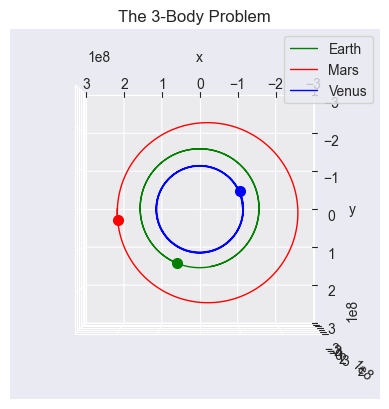

In [12]:
# -------  Plotting the solutions ------- #

fig, ax = plt.subplots(subplot_kw={"projection":"3d"})

planet1_plt, = ax.plot(p1x_sol, p1y_sol, p1z_sol, 'green', label='Earth', linewidth=1)
planet2_plt, = ax.plot(p2x_sol, p2y_sol, p2z_sol, 'red', label='Mars', linewidth=1)
planet3_plt, = ax.plot(p3x_sol, p3y_sol, p3z_sol, 'blue',label='Venus', linewidth=1)

planet1_dot, = ax.plot([p1x_sol[-1]], [p1y_sol[-1]], [p1z_sol[-1]], 'o', color='green', markersize=7)
planet2_dot, = ax.plot([p2x_sol[-1]], [p2y_sol[-1]], [p2z_sol[-1]], 'o', color='red', markersize=7)
planet3_dot, = ax.plot([p3x_sol[-1]], [p3y_sol[-1]], [p3z_sol[-1]], 'o', color='blue', markersize=7)


ax.set_title("The 3-Body Problem")
ax.set_xlabel("x")
ax.set_xlim(-3e8,3e8)
ax.set_ylabel("y")
ax.set_ylim(-3e8,3e8)
ax.set_zlabel("z")
ax.set_zlim(-3e8,3e8)

ax.view_init(90,90)
plt.grid()
plt.legend()
plt.show()

In [13]:
def tc2array(tcs, steps):
    arr = np.zeros((steps, 1))
    arr[:,0] = np.linspace(tcs[0], tcs[1], steps)
    return arr

def get_ephemeris_data(target, times, frame, observer):
    return np.array(spice.spkezr(target, times, frame, "NONE", observer)[0])

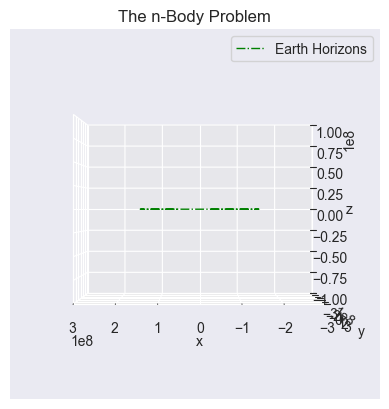

In [14]:
# -------  Plotting the solutions ------- #

fig, ax = plt.subplots(subplot_kw={"projection":"3d"})

earth_hor_plt, = ax.plot(earthx, earthy, earthz,'g-.', label='Earth Horizons', linewidth=1)
# mars_hor_plt, = ax.plot(marsx, marsy, marsz,  'r-.', label='Mars Horizons', linewidth=1)
# venus_hor_plt, = ax.plot(venusx, venusy, venusz,  'b-.', label='Venus Horizons', linewidth=1)

# planet1_plt, = ax.plot(p1x_sol, p1y_sol, p1z_sol, 'green', label='Earth Sim', linewidth=1)
# planet2_plt, = ax.plot(p2x_sol, p2y_sol, p2z_sol, 'red', label='Mars Sim', linewidth=1)
# planet3_plt, = ax.plot(p3x_sol, p3y_sol, p3z_sol, 'blue',label='Venus Sim', linewidth=1)


ax.set_title("The n-Body Problem")
ax.set_xlabel("x")
ax.set_xlim(-3e8,3e8)
ax.set_ylabel("y")
ax.set_ylim(-3e8,3e8)
ax.set_zlabel("z")
ax.set_zlim(-1e8,1e8)

ax.view_init(0,90)
plt.grid()
plt.legend()
plt.show()

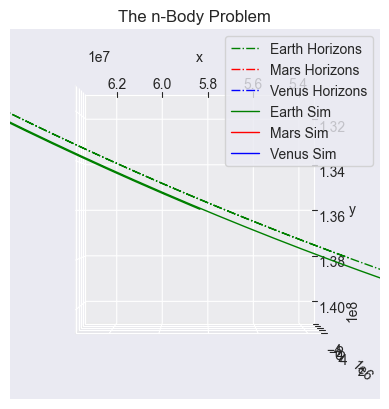

In [15]:
# -------  Plotting the solutions ------- #
scale = 5e6
fig, ax = plt.subplots(subplot_kw={"projection":"3d"})

earth_hor_plt, = ax.plot(earthx, earthy, earthz,'g-.', label='Earth Horizons', linewidth=1)
mars_hor_plt, = ax.plot(marsx, marsy, marsz,  'r-.', label='Mars Horizons', linewidth=1)
venus_hor_plt, = ax.plot(venusx, venusy, venusz,  'b-.', label='Venus Horizons', linewidth=1)

planet1_plt, = ax.plot(p1x_sol, p1y_sol, p1z_sol, 'green', label='Earth Sim', linewidth=1)
planet2_plt, = ax.plot(p2x_sol, p2y_sol, p2z_sol, 'red', label='Mars Sim', linewidth=1)
planet3_plt, = ax.plot(p3x_sol, p3y_sol, p3z_sol, 'blue',label='Venus Sim', linewidth=1)


ax.set_title("The n-Body Problem")
ax.set_xlabel("x")
ax.set_xlim(p1x_sol[-1] - scale, p1x_sol[-1] + scale)
ax.set_ylabel("y")
ax.set_ylim(p1y_sol[-1] - scale, p1y_sol[-1] + scale)
ax.set_zlabel("z")
ax.set_zlim(p1z_sol[-1] - scale, p1z_sol[-1] + scale)

ax.view_init(90,90)
plt.grid()
plt.legend()
plt.show()

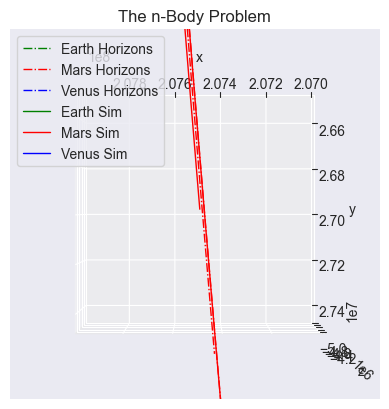

In [16]:
# -------  Plotting the solutions ------- #
scale = 5e5
fig, ax = plt.subplots(subplot_kw={"projection":"3d"})

earth_hor_plt, = ax.plot(earthx, earthy, earthz,'g-.', label='Earth Horizons', linewidth=1)
mars_hor_plt, = ax.plot(marsx, marsy, marsz,  'r-.', label='Mars Horizons', linewidth=1)
venus_hor_plt, = ax.plot(venusx, venusy, venusz,  'b-.', label='Venus Horizons', linewidth=1)

planet1_plt, = ax.plot(p1x_sol, p1y_sol, p1z_sol, 'green', label='Earth Sim', linewidth=1)
planet2_plt, = ax.plot(p2x_sol, p2y_sol, p2z_sol, 'red', label='Mars Sim', linewidth=1)
planet3_plt, = ax.plot(p3x_sol, p3y_sol, p3z_sol, 'blue',label='Venus Sim', linewidth=1)


ax.set_title("The n-Body Problem")
ax.set_xlabel("x")
ax.set_xlim(p2x_sol[-1] - scale, p2x_sol[-1] + scale)
ax.set_ylabel("y")
ax.set_ylim(p2y_sol[-1] - scale, p2y_sol[-1] + scale)
ax.set_zlabel("z")
ax.set_zlim(p2z_sol[-1] - scale, p2z_sol[-1] + scale)

ax.view_init(90,90)
plt.grid()
plt.legend()
plt.show()

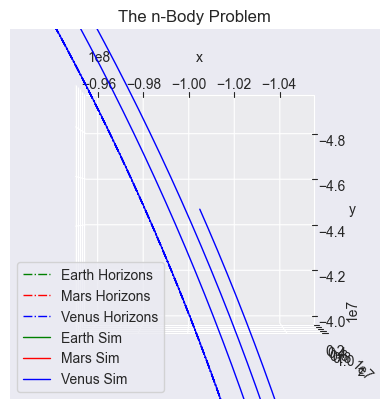

In [17]:
# -------  Plotting the solutions ------- #
scale = 5e6
fig, ax = plt.subplots(subplot_kw={"projection":"3d"})

earth_hor_plt, = ax.plot(earthx, earthy, earthz,'g-.', label='Earth Horizons', linewidth=1)
mars_hor_plt, = ax.plot(marsx, marsy, marsz,  'r-.', label='Mars Horizons', linewidth=1)
venus_hor_plt, = ax.plot(venusx, venusy, venusz,  'b-.', label='Venus Horizons', linewidth=1)

planet1_plt, = ax.plot(p1x_sol, p1y_sol, p1z_sol, 'green', label='Earth Sim', linewidth=1)
planet2_plt, = ax.plot(p2x_sol, p2y_sol, p2z_sol, 'red', label='Mars Sim', linewidth=1)
planet3_plt, = ax.plot(p3x_sol, p3y_sol, p3z_sol, 'blue',label='Venus Sim', linewidth=1)


ax.set_title("The n-Body Problem")
ax.set_xlabel("x")
ax.set_xlim(p3x_sol[-1] - scale, p3x_sol[-1] + scale)
ax.set_ylabel("y")
ax.set_ylim(p3y_sol[-1] - scale, p3y_sol[-1] + scale)
ax.set_zlabel("z")
ax.set_zlim(p3z_sol[-1] - scale, p3z_sol[-1] + scale)

ax.view_init(90,90)
plt.grid()
plt.legend()
plt.show()

In [18]:
earth_pos = earth[:,:3]

earth_sim = np.array([p1x_sol,p1y_sol,p1z_sol]).T
earth_sim

deviation = []
for i in range(len(earth_pos)):
    deviation.append(np.linalg.norm(earth_pos[i,:] - earth_sim[i,:]) )
    print(np.linalg.norm(earth_pos[i,:] - earth_sim[i,:]))
    # print(earth_pos[i,:])

max(deviation)

0.0
35.41449241194181
34.56175816635823
33.49702558443542
32.791715557195545
33.12802251515643
35.05986469756935
38.76749490685063
44.03324644885541
50.42891250950804
58.6036392897493
69.33574293499763
82.1965514645485
96.77124938112046
112.68994715316376
129.62520956344986
147.28261447340063
165.39293888130396
184.31831278344137
205.20809335752634
227.8268257476842
251.89818491667106
277.15962356239714
303.3593600306705
330.25466532437804
357.61117528874166
385.30088059398724
413.6964399601199
442.88777374736486
472.90435813930645
503.7747225866105
535.5263787838172
568.1857674969309
601.7782184221538
636.3279228820307
671.8579148552872
708.3900609387719
745.9450566697789
784.5424284494954
824.2005402681001
864.9366039084398
906.7666929458734
949.7057583309465
993.7676464739005
1038.9651186700798
1085.3098712457838
1132.8125569270335
1181.482805849503
1231.3292473618103
1282.3595312132302
1334.5803488647462
1387.9974539271316
1442.6156827235127
1498.4389733077426
1555.4703847370085
16

np.float64(6644745.661144025)

In [19]:
mars_pos = mars[:,:3]

mars_sim = np.array([p2x_sol,p2y_sol,p2z_sol]).T

deviation = []
for i in range(len(mars_pos)):
    deviation.append(np.linalg.norm(mars_pos[i,:] - mars_sim[i,:]) )
    print(np.linalg.norm(mars_pos[i,:] - mars_sim[i,:]))
    # print(earth_pos[i,:])

max(deviation)

0.0
17.84200297558087
17.81618702267634
17.777339301248215
17.7455362364113
17.735254561643796
17.749154664797278
17.77573886167905
17.791413389787667
17.767132090345196
17.736800249371267
17.75612241886648
17.82678635889352
17.944839235677307
18.094457260069742
18.246063692154333
18.358073278529098
18.381692962026648
18.353660696623926
18.44017893260316
18.629939344042015
18.899006837431834
19.212546659882324
19.52344226688611
19.774330822758568
19.901321090574868
19.849657602099345
19.635747237921105
19.265277321296818
18.740194399675048
18.06387412902712
17.240760701007662
16.276871780790913
15.180939223905202
13.9655865578017
12.649067020621986
11.259379217342534
9.843332576023629
8.483676806814444
7.328442811909248
6.620187103816037
6.642248781289474
7.51072850707122
9.085630808218939
11.152605794470663
13.555745291799212
16.202917850237537
19.040454435595457
22.035264067635264
25.165738065736164
28.417074456184757
31.778152367311712
35.23967310770985
38.793571805756685
42.4330592

np.float64(613001.1136087656)

In [20]:
venus_pos = venus[:,:3]

venus_sim = np.array([p3x_sol,p3y_sol,p3z_sol]).T

deviation = []
for i in range(len(venus_pos)):
    deviation.append(np.linalg.norm(venus_pos[i,:] - venus_sim[i,:]) )
    print(np.linalg.norm(venus_pos[i,:] - venus_sim[i,:]))
    # print(earth_pos[i,:])

max(deviation)

1.4930236657970956e-08
66.57145148518957
66.51373997714093
66.65683363783943
67.34436202324957
68.7545440318876
70.75859189511984
72.92094299434353
74.60741593052447
75.13637257916845
75.5970526506944
77.46078525567668
80.53038148928806
84.49788874841033
88.87376210727568
93.0090812894214
96.15836472211792
97.54520422884555
97.97650203495556
100.45244724705138
104.58032645568966
109.7748072556823
115.37201623368874
120.63683293459195
124.78711276105082
127.01915505584415
126.69635859741213
124.19658227321361
119.65480856215933
113.13108809292925
104.7068593855041
94.50290643208098
82.71886573988958
69.7292739438652
56.34279740468978
44.53309386279139
38.85901456171799
44.64821900261126
60.72303201411025
82.81992572589303
108.57761785414793
136.9970138468531
167.62109686530437
200.20831869613434
234.61120344441895
270.7273137602922
308.47742067070993
347.79490536961646
388.620222929801
430.89782655750037
474.5743667751333
519.5975886158451
565.9156293469773
613.4765547995219
662.2280439

np.float64(38566202.78552304)

## 2D Projection of Ephemeris data

In [21]:
projection_matrix = [[1,0,0],
                     [0,1,0],
                     [0,0,0]]

earth_2D = []

for i in range(len(earth_pos)):
    projected_v = projection_matrix @ earth_pos[i,:]

    earth_2D.append([projected_v])
    # print(projected_v)

earth_2D = np.array(earth_2D)
earth_2Dx = earth_2D[:,0,0]
earth_2Dy = earth_2D[:,0,1]
earth_2Dz = earth_2D[:,0,2]

earth_2Dx

array([-26499033.67742509, -26679227.52629079, -26859381.46909883, ...,
        52379247.88019352,  52207913.38121004,  52036500.18970905],
      shape=(10000,))

In [22]:
earthx

array([-26499033.67742509, -26679227.52629079, -26859381.46909883, ...,
        52379247.88019352,  52207913.38121004,  52036500.18970905],
      shape=(10000,))

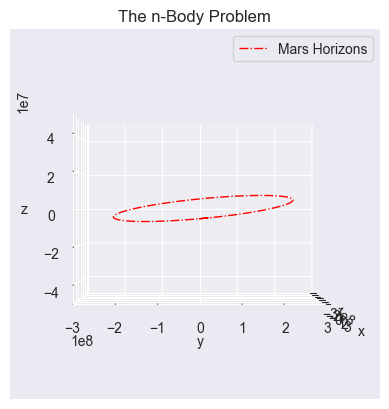

In [23]:
# -------  Plotting the solutions ------- #

fig, ax = plt.subplots(subplot_kw={"projection":"3d"})

# earth_hor_plt, = ax.plot(earthx, earthy, earthz,'g-.', label='Earth Horizons', linewidth=1)
mars_hor_plt, = ax.plot(marsx, marsy, marsz,  'r-.', label='Mars Horizons', linewidth=1)
# venus_hor_plt, = ax.plot(venusx, venusy, venusz,  'b-.', label='Venus Horizons', linewidth=1)

# planet1_plt, = ax.plot(earth_2Dx, earth_2Dy, earth_2Dz, 'green', label='Earth 2D', linewidth=1)
# planet2_plt, = ax.plot(p2x_sol, p2y_sol, p2z_sol, 'red', label='Mars 2D', linewidth=1)
# planet3_plt, = ax.plot(p3x_sol, p3y_sol, p3z_sol, 'blue',label='Venus 2D', linewidth=1)


ax.set_title("The n-Body Problem")
ax.set_xlabel("x")
ax.set_xlim(-3e8,3e8)
ax.set_ylabel("y")
ax.set_ylim(-3e8,3e8)
ax.set_zlabel("z")
ax.set_zlim(-0.5e8,0.5e8)

ax.view_init(0,0)
plt.grid()
plt.legend()
plt.show()

## MAPPING TO 2D

In [24]:
def angle_vector_plane(vector):
    normal = [0,0,1]
    v_unit = vector / np.linalg.norm(vector)
    n_unit = normal / np.linalg.norm(normal)
    
    dot_product = np.dot(v_unit, n_unit)
    alpha = np.arccos(dot_product)
    
    theta_rad = (np.pi / 2) - alpha
    return theta_rad

# Example: Plane is the XY plane (normal is Z-axis [0,0,1])
# Vector is at 45 degrees to the XY plane [1, 0, 1]
vec = np.array([10, 0, 1])


print(f"Angle: {angle_vector_plane(vec):.2f} rad")

Angle: 0.10 rad


In [25]:
def perpendicular_norm( a ) :
    perp = np.cross([0,0,1], a ) ## FUCKS SAKE
    return perp/np.linalg.norm(perp)


# print(angle_vector_plane(perp))


In [26]:
from scipy.spatial.transform import Rotation as R

perp_unit = perpendicular_norm(earth_pos[0])

r = R.from_rotvec(angle_vector_plane(earth_pos[0]) * perp_unit )
print(earth_pos[0])
print(angle_vector_plane(earth_pos[0]))
earth_pos_rot = r.apply(earth_pos[0])
earth_pos_rot

[-2.64990337e+07  1.44697297e+08 -6.11149426e+02]
-4.154547533996578e-06


array([-2.64990337e+07,  1.44697297e+08,  2.02622965e-08])

In [27]:
def map_to_2D(a):
    perp_unit = perpendicular_norm(a)
    r = R.from_rotvec(angle_vector_plane(a) * perp_unit )
    # print(a)
    # print(perp_unit)
    # print(angle_vector_plane(a))
    earth_pos_rot = r.apply(a)
    # print(earth_pos_rot)
    return earth_pos_rot

In [56]:
earth_pos = earth[:,:3]

earth_2D = []
for i in range(len(earth_pos)):
    earth_2D.append(map_to_2D(earth_pos[i])) 
    # print(earth_pos[i,:])


earth_2D = np.array(earth_2D)
earth_2Dx = earth_2D[:,0]
earth_2Dy = earth_2D[:,1]
earth_2Dz = earth_2D[:,2]

earth_2D

array([[-2.64990337e+07,  1.44697297e+08,  2.02622965e-08],
       [-2.66792275e+07,  1.44664104e+08,  1.06073022e-08],
       [-2.68593815e+07,  1.44630691e+08,  7.43832936e-10],
       ...,
       [ 5.23792479e+07,  1.37891264e+08,  7.68338381e-09],
       [ 5.22079134e+07,  1.37954451e+08,  1.83489610e-08],
       [ 5.20365002e+07,  1.38017430e+08,  1.22157577e-09]],
      shape=(10000, 3))

In [29]:
earth_pos

array([[-2.64990337e+07,  1.44697297e+08, -6.11149426e+02],
       [-2.66792275e+07,  1.44664104e+08, -6.09999614e+02],
       [-2.68593815e+07,  1.44630691e+08, -6.08749487e+02],
       ...,
       [ 5.23792479e+07,  1.37891264e+08, -6.77362854e+02],
       [ 5.22079134e+07,  1.37954451e+08, -6.84690968e+02],
       [ 5.20365002e+07,  1.38017430e+08, -6.92039707e+02]],
      shape=(10000, 3))

In [30]:
mars_pos = mars[:,:3]

mars_2D = []
for i in range(len(mars_pos)):
    mars_2D.append(map_to_2D(mars_pos[i])) 
    # print(earth_pos[i,:])


mars_2D = np.array(mars_2D)
mars_2Dx = mars_2D[:,0]
mars_2Dy = mars_2D[:,1]
mars_2Dz = mars_2D[:,2]

mars_2Dx

array([2.08112022e+08, 2.08118919e+08, 2.08125704e+08, ...,
       2.07504520e+08, 2.07490930e+08, 2.07477230e+08], shape=(10000,))

In [31]:
venus_pos = venus[:,:3]

venus_2D = []
for i in range(len(venus_pos)):
    venus_2D.append(map_to_2D(venus_pos[i])) 
    # print(earth_pos[i,:])


venus_2D = np.array(venus_2D)
venus_2Dx = venus_2D[:,0]
venus_2Dy = venus_2D[:,1]
venus_2Dz = venus_2D[:,2]

venus_2Dx

array([-1.07631160e+08, -1.07622381e+08, -1.07613183e+08, ...,
       -7.77654341e+07, -7.76191326e+07, -7.74725352e+07], shape=(10000,))

In [32]:
mars_2Dz

array([3.35848255e-08, 9.87247558e-09, 2.69523324e-08, ...,
       2.08407375e-08, 4.73090035e-09, 8.24693737e-09], shape=(10000,))

In [33]:
mars_pos

array([[ 2.08048141e+08, -2.00705263e+06, -5.15628896e+06],
       [ 2.08055117e+08, -1.84799760e+06, -5.15312840e+06],
       [ 2.08061982e+08, -1.68894156e+06, -5.14996507e+06],
       ...,
       [ 2.07455968e+08,  2.72691126e+07, -4.52716842e+06],
       [ 2.07442462e+08,  2.74269115e+07, -4.52353116e+06],
       [ 2.07428847e+08,  2.75846959e+07, -4.51989151e+06]],
      shape=(10000, 3))

In [34]:
max(venusx)

np.float64(108514184.07886253)

In [35]:
print(venus[1,:3])
print(venus_2D[1])


[-1.07447927e+08 -5.09755509e+06  6.13223501e+06]
[-1.07622381e+08 -5.10583155e+06 -2.64280185e-09]


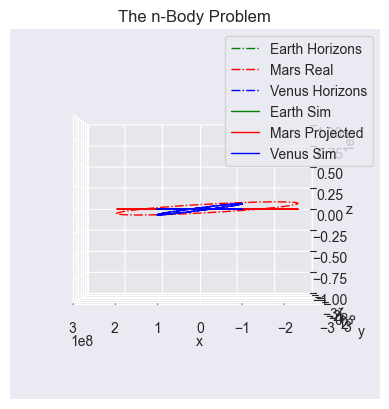

In [36]:
# -------  Plotting the solutions ------- #

fig, ax = plt.subplots(subplot_kw={"projection":"3d"})

earth_hor_plt, = ax.plot(earthx, earthy, earthz,'g-.', label='Earth Horizons', linewidth=1)
mars_hor_plt, = ax.plot(marsx, marsy, marsz,  'r-.', label='Mars Real', linewidth=1)
venus_hor_plt, = ax.plot(venusx, venusy, venusz,  'b-.', label='Venus Horizons', linewidth=1)

planet1_plt, = ax.plot(earth_2Dx, earth_2Dy, earth_2Dz, 'green', label='Earth Sim', linewidth=1)
planet2_plt, = ax.plot(mars_2Dx, mars_2Dy, mars_2Dz, 'red', label='Mars Projected', linewidth=1)
planet3_plt, = ax.plot(venus_2Dx, venus_2Dy, venus_2Dz, 'blue',label='Venus Sim', linewidth=1)


ax.set_title("The n-Body Problem")
ax.set_xlabel("x")
ax.set_xlim(-3e8,3e8)
ax.set_ylabel("y")
ax.set_ylim(-3e8,3e8)
ax.set_zlabel("z")
ax.set_zlim(-1e8,1e8)

ax.view_init(0,90)
plt.grid()
plt.legend()
plt.show()

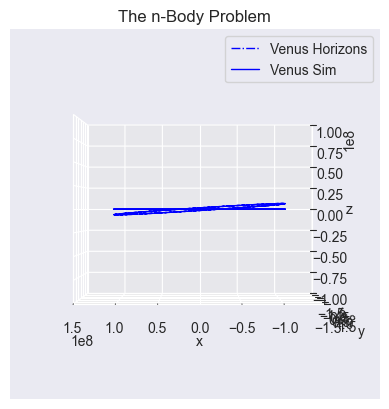

In [37]:
# -------  Plotting the solutions ------- #

fig, ax = plt.subplots(subplot_kw={"projection":"3d"})

# earth_hor_plt, = ax.plot(earthx, earthy, earthz,'g-.', label='Earth Horizons', linewidth=1)
# mars_hor_plt, = ax.plot(marsx, marsy, marsz,  'r-.', label='Mars Real', linewidth=1)
venus_hor_plt, = ax.plot(venusx, venusy, venusz,  'b-.', label='Venus Horizons', linewidth=1)

# planet1_plt, = ax.plot(earth_2Dx, earth_2Dy, earth_2Dz, 'green', label='Earth Sim', linewidth=1)
# planet2_plt, = ax.plot(mars_2Dx, mars_2Dy, mars_2Dz, 'red', label='Mars Projected', linewidth=1)
planet3_plt, = ax.plot(venus_2Dx, venus_2Dy, venus_2Dz, 'blue',label='Venus Sim', linewidth=1)


ax.set_title("The n-Body Problem")
ax.set_xlabel("x")
ax.set_xlim(-1.5e8,1.5e8)
ax.set_ylabel("y")
ax.set_ylim(-1.5e8,1.5e8)
ax.set_zlabel("z")
ax.set_zlim(-1e8,1e8)

ax.view_init(0,90)
plt.grid()
plt.legend()
plt.show()

## Examine Circular-Planar

In [38]:
t_points


array([0.00000000e+00, 6.04860486e+03, 1.20972097e+04, ...,
       6.04679028e+07, 6.04739514e+07, 6.04800000e+07], shape=(10000,))

In [39]:
venus_2D[0]

array([-1.07631160e+08, -4.89295531e+06,  8.79525054e-09])

In [40]:
np.arctan(venus_2D[0,1]/venus_2D[0,0])

np.float64(0.045429119479178416)

In [41]:
earth_2D[0]

array([-2.64990337e+07,  1.44697297e+08,  2.02622965e-08])

In [42]:
np.arctan(earth_2D[0,1]/earth_2D[0,0])

np.float64(-1.389669150302389)

In [43]:
init_phase_earth = np.arccos(earth_2D[0,0]/D_earth) 
init_phase_venus = np.arccos(venus_2D[0,0]/D_venus) 
init_phase_mars = np.arccos(mars_2D[0,0]/D_mars) 


In [44]:
r_earth = []
r_mars = []
r_venus = []


for t in t_points:
    rx_earth = D_earth*np.cos(w_earth*t + init_phase_earth)
    ry_earth = D_earth*np.sin(w_earth*t + init_phase_earth)
    r_earth.append([rx_earth,ry_earth,0])
    
    rx_mars = D_mars*np.cos(w_mars*t + init_phase_mars)
    ry_mars = D_mars*np.sin(w_mars*t + init_phase_mars)
    r_mars.append([rx_mars,ry_mars,0])

    rx_venus = D_venus*np.cos(w_venus*t + init_phase_venus)
    ry_venus = D_venus*np.sin(w_venus*t + init_phase_venus)
    r_venus.append([rx_venus, ry_venus, 0])

r_earth = np.array(r_earth)
rx_earth = r_earth[:,0]
ry_earth = earth_2D[:,1]

r_mars = np.array(r_mars)
rx_mars = r_mars[:,0]
ry_mars = r_mars[:,1]

r_venus = np.array(r_venus)
rx_venus = r_venus[:,0]
ry_venus = r_venus[:,1]

In [45]:
r_earth[:,0]

array([-26499033.6776538 , -26676394.53564394, -26853716.67512827, ...,
        50516135.82506352,  50346455.29498942,  50176701.69134036],
      shape=(10000,))

In [46]:
t_o_f_venus = 60*60*24*150 # Approximate time of flight of optimal venus mission.

index_venus = int(t_o_f_venus*ts/time_e)
print(index_venus)

2142


In [47]:
t_o_f_mars = 60*60*24*260 # Approximate time of flight of optimal mars mission.

index_mars = int(t_o_f_mars*ts/time_e)
print(index_mars)

3714


In [48]:
venus_2D[0,:]

array([-1.07631160e+08, -4.89295531e+06,  8.79525054e-09])

In [49]:
venus_pos[0,:]

array([-1.07456494e+08, -4.88501495e+06,  6.13563440e+06])

In [50]:
r_venus[0,:]

array([-1.07631160e+08,  1.05809255e+07,  0.00000000e+00])

In [51]:
deviation_v = []
for i in range(int(index_venus)):
    deviation_v.append(np.linalg.norm(venus_2D[i,:] - r_venus[i,:]) )
    print(np.linalg.norm(venus_2D[i,:] - r_venus[i,:]))
    # print(earth_pos[i,:])

max_deviation_venus = max(deviation_v)

15473880.789194014
15475925.040837057
15477964.31476783
15479998.59930221
15482027.882784983
15484052.153590351
15486071.400121689
15488085.610811768
15490094.774123015
15492098.878547268
15494097.912606254
15496091.8648513
15498080.723863814
15500064.478255047
15502043.116666334
15504016.627769317
15505985.000265727
15507948.22288785
15509906.284398267
15511859.173590133
15513806.87928737
15515749.390344456
15517686.695646893
15519618.7841109
15521545.644683907
15523467.266344307
15525383.638101682
15527294.748997053
15529200.588102618
15531101.144522239
15532996.407391189
15534886.36587639
15536771.009176647
15538650.32652239
15540524.307176163
15542392.940432323
15544256.2156175
15546114.12209036
15547966.649241844
15549813.786495375
15551655.523306644
15553491.849164035
15555322.753588418
15557148.226133352
15558968.25638532
15560782.833963497
15562591.948520187
15564395.589740587
15566193.747343024
15567986.411079168
15569773.570733782
15571555.216125187
15573331.337104993
1557510

In [52]:
venus_percent_error = ((np.linalg.norm(r_venus[0]) - np.linalg.norm(venus_2D[0]))/np.linalg.norm(venus_2D[0]) ) *100
print(venus_percent_error)

venus_percent_error = (((np.linalg.norm(r_venus[index_venus]) - np.linalg.norm(venus_2D[index_venus]))/np.linalg.norm(venus_2D[index_venus]) )) * 100
print(venus_percent_error)


0.37838424115518365
0.1776794040946443


In [53]:
mars_percent_error = ((np.linalg.norm(r_mars[0]) - np.linalg.norm(mars_2D[0]))/np.linalg.norm(mars_2D[0]) ) *100
print(mars_percent_error)

mars_percent_error = (((np.linalg.norm(r_mars[index_mars]) - np.linalg.norm(mars_2D[index_mars]))/np.linalg.norm(mars_2D[index_mars]) )) * 100
print(mars_percent_error)


9.5032347483429
-7.970489716775381


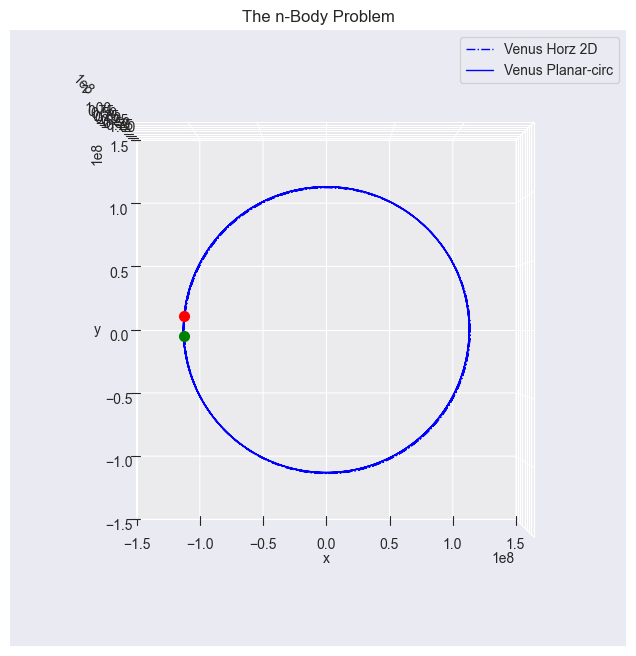

In [54]:
# -------  Plotting the solutions ------- #

fig, ax = plt.subplots(figsize = (13,8),subplot_kw={"projection":"3d"})

# earth_hor_plt, = ax.plot(earth_2Dx, earth_2Dy, earth_2Dy,'g-.', label='Earth Horz 2D', linewidth=1)
# mars_hor_plt, = ax.plot(mars_2Dx, mars_2Dy, mars_2Dz,  'r-.', label='Mars Horz 2D', linewidth=1)
venus_hor_plt, = ax.plot(venus_2Dx, venus_2Dy, venus_2Dz,  'b-.', label='Venus Horz 2D', linewidth=1)

# planet1_plt, = ax.plot(rx_earth, ry_earth, 0, 'green', label='Mars Planar-circ', linewidth=1)
# planet2_plt, = ax.plot(rx_mars, ry_mars, 0, 'red', label='Mars Planar-circ', linewidth=1)
planet3_plt, = ax.plot(rx_venus, ry_venus, 0, 'blue',label='Venus Planar-circ', linewidth=1)

planet1_dot, = ax.plot([venus_2Dx[0]], [venus_2Dy[0]], [venus_2Dz[0]], 'o', color='green', markersize=7)
planet2_dot, = ax.plot([rx_venus[0]], [ry_venus[0]], 0, 'o', color='red', markersize=7)
# planet3_dot, = ax.plot([p3x_sol[-1]], [p3y_sol[-1]], [p3z_sol[-1]], 'o', color='blue', markersize=7)

ax.set_title("The n-Body Problem")
ax.set_xlabel("x")
ax.set_xlim(-1.5e8,1.5e8)
ax.set_ylabel("y")
ax.set_ylim(-1.5e8,1.5e8)
ax.set_zlabel("z")
ax.set_zlim(-1e8,1e8)

ax.view_init(90,-90)
plt.grid()
plt.legend()
plt.show()

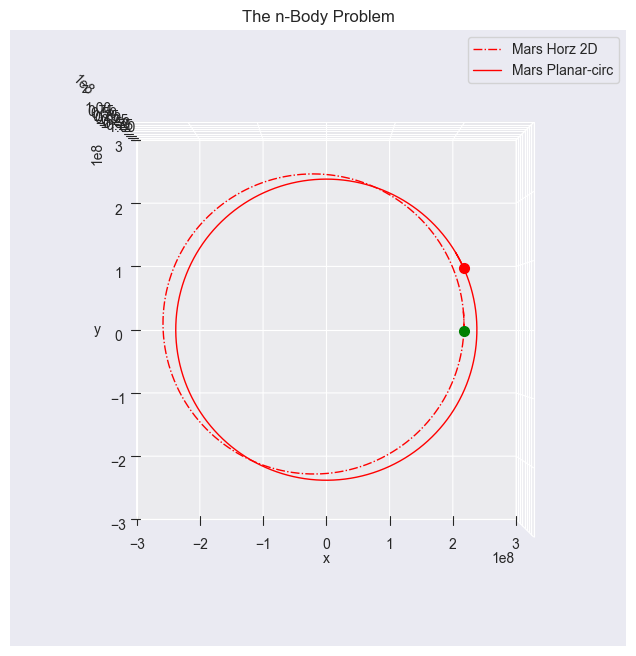

In [55]:
# -------  Plotting the solutions ------- #

fig, ax = plt.subplots(figsize = (13,8),subplot_kw={"projection":"3d"})

# earth_hor_plt, = ax.plot(earth_2Dx, earth_2Dy, earth_2Dy,'g-.', label='Earth Horz 2D', linewidth=1)
mars_hor_plt, = ax.plot(mars_2Dx, mars_2Dy, mars_2Dz,  'r-.', label='Mars Horz 2D', linewidth=1)
# venus_hor_plt, = ax.plot(venus_2Dx, venus_2Dy, venus_2Dz,  'b-.', label='Venus Horz 2D', linewidth=1)

# planet1_plt, = ax.plot(rx_earth, ry_earth, 0, 'green', label='Mars Planar-circ', linewidth=1)
planet2_plt, = ax.plot(rx_mars, ry_mars, 0, 'red', label='Mars Planar-circ', linewidth=1)
# planet3_plt, = ax.plot(rx_venus, ry_venus, 0, 'blue',label='Venus Planar-circ', linewidth=1)

planet1_dot, = ax.plot([mars_2Dx[0]], [mars_2Dy[0]], [mars_2Dz[0]], 'o', color='green', markersize=7)
planet2_dot, = ax.plot([rx_mars[0]], [ry_mars[0]], 0, 'o', color='red', markersize=7)
# planet3_dot, = ax.plot([p3x_sol[-1]], [p3y_sol[-1]], [p3z_sol[-1]], 'o', color='blue', markersize=7)

ax.set_title("The n-Body Problem")
ax.set_xlabel("x")
ax.set_xlim(-3e8,3e8)
ax.set_ylabel("y")
ax.set_ylim(-3e8,3e8)
ax.set_zlabel("z")
ax.set_zlim(-1e8,1e8)

ax.view_init(90,-90)
plt.grid()
plt.legend()
plt.show()